## GEOG5990M Final Assignment

(The cover sheet has been adapted from the word doc. to support use with .ipynb files - please complete all the requested info.)
COURSEWORK COVERSHEET

    Student ID number: 201559628
    Module code: GEOG5990M
    Module title: Programming for Spatial Data Science
    Assignment title: Final Project
    Marker:
    Declared word count: 1472

Use of Generative Artificial Intelligence (Gen AI) in this assessment – delete one statement as appropriate

    I have made no use of Gen AI

By submitting the work in this notebook you confirm your compliance with the University’s definition of Academic Integrity as: “a commitment to good study practices and shared values which ensures that my work is a true expression of my own understanding and ideas, giving credit to others where their work contributes to mine”. Double-check that your referencing and use of quotations is consistent with this commitment.

You also confirm that your declared word count accurately reflects the number of words in your submission, excluding the overall title, Gen AI use acknowledgement, bibliography/reference list, text/numbers in tables and figures (although table and figure captions are included in the word count).

## Section 0: Setup

In [55]:
# Install resources
!pip install git+https://github.com/pmdscully/geo_northarrow.git
!pip install contextily
!pip install matplotlib-scalebar

  Cloning https://github.com/pmdscully/geo_northarrow.git to /tmp/pip-req-build-xxq_pln_
  Running command git clone --filter=blob:none --quiet https://github.com/pmdscully/geo_northarrow.git /tmp/pip-req-build-xxq_pln_
  Resolved https://github.com/pmdscully/geo_northarrow.git to commit 9dc0fd83b20f48ff00ffb977bd44c09eaf4689d8
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [56]:
# Load in required packages

import pandas as pd
import geopandas as gpd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns
from geo_northarrow import add_north_arrow
from matplotlib_scalebar.scalebar import ScaleBar
import contextily as ctx

## 1. Data Loading

In [3]:
# Load in Attendance dataset
raw_attendance = pd.read_csv('Secondary Attendance 18.19.csv')

In [4]:
# Use .head() to view the first 5 rows of the dataset and see the names used for different columns
raw_attendance.head()

,LSOA11,Total of possible sessions,Total sessions attended,Total sessions missed,Attendance (%)
0,E01010568,9982,9450,532,94.7%
1,E01010569,2574,2500,74,97.1%
2,E01010570,2263,2220,43,98.1%
3,E01010571,6067,5835,232,96.2%
4,E01010572,6507,6275,232,96.4%


In [5]:
# Check the shape of and different data types used in the dataset
raw_attendance.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 819 entries, 0 to 818
Data columns (total 5 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   LSOA11                      819 non-null    object
 1   Total of possible sessions  819 non-null    int64 
 2   Total sessions attended     819 non-null    int64 
 3   Total sessions missed       819 non-null    int64 
 4   Attendance (%)              819 non-null    object
dtypes: int64(3), object(2)
memory usage: 32.1+ KB


In [6]:
# The attendance data set uses a percentage system to show school attendance in different LSOAs, and appears non-numeric due to the use of a % sign within each cell.
# The count is much higher than expected, being 819 instead of the expected 482 (the number of LSOAs in the 2011 census).

In [7]:
# Load in Indices of Deprivation dataset
raw_deprivation = pd.read_csv('Deprivation.csv')

In [8]:
# Use .head() to view the first 5 rows of the dataset and see the names used for different columns
raw_deprivation.head(11)

,lsoalabel,indlabel,observation,JSONBoundary,JSONPBoundary
0,Leeds 001A E01011698,a. Index of Multiple Deprivation (IMD),9,http://maps.communities.gov.uk/geoserver/ows?s...,http://maps.communities.gov.uk/geoserver/ows?s...
1,Leeds 001A E01011698,b. Income Deprivation Domain,10,http://maps.communities.gov.uk/geoserver/ows?s...,http://maps.communities.gov.uk/geoserver/ows?s...
2,Leeds 001A E01011698,c. Employment Deprivation Domain,8,http://maps.communities.gov.uk/geoserver/ows?s...,http://maps.communities.gov.uk/geoserver/ows?s...
3,Leeds 001A E01011698,"d. Education, Skills and Training Domain",8,http://maps.communities.gov.uk/geoserver/ows?s...,http://maps.communities.gov.uk/geoserver/ows?s...
4,Leeds 001A E01011698,e. Health Deprivation and Disability Domain,6,http://maps.communities.gov.uk/geoserver/ows?s...,http://maps.communities.gov.uk/geoserver/ows?s...
5,Leeds 001A E01011698,f. Crime Domain,10,http://maps.communities.gov.uk/geoserver/ows?s...,http://maps.communities.gov.uk/geoserver/ows?s...
6,Leeds 001A E01011698,g. Barriers to Housing and Services Domain,8,http://maps.communities.gov.uk/geoserver/ows?s...,http://maps.communities.gov.uk/geoserver/ows?s...
7,Leeds 001A E01011698,h. Living Environment Deprivation Domain,8,http://maps.communities.gov.uk/geoserver/ows?s...,http://maps.communities.gov.uk/geoserver/ows?s...
8,Leeds 001A E01011698,i. Income Deprivation Affecting Children Index...,10,http://maps.communities.gov.uk/geoserver/ows?s...,http://maps.communities.gov.uk/geoserver/ows?s...
9,Leeds 001A E01011698,j. Income Deprivation Affecting Older People I...,9,http://maps.communities.gov.uk/geoserver/ows?s...,http://maps.communities.gov.uk/geoserver/ows?s...


In [9]:
# Check the shape of and different data types used in the dataset
raw_deprivation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4820 entries, 0 to 4819
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   lsoalabel      4820 non-null   object
 1   indlabel       4820 non-null   object
 2   observation    4820 non-null   int64 
 3   JSONBoundary   4820 non-null   object
 4   JSONPBoundary  4820 non-null   object
dtypes: int64(1), object(4)
memory usage: 188.4+ KB


In [10]:
# The Deprivation dataset uses multiple rows for each LSOA (10 for each), rather than using a separate column for each of its deprivation measures
# This report is only interested in the Index of Multiple Deprivation Score (IMD) as it provides the best holistic view of deprivation in each LSOA, other layers will be removed in data cleaning
# The count is expected, being 4820. This is due to the dataset having 10 rows for each LSOA, as mentioned above

In [11]:
# Load in the Leeds LSOA geometry dataset
raw_leeds_lsoa = gpd.read_file('leeds_lsoa_2011.gpkg')

In [12]:
# Use .head() to view the first 5 rows of the dataset and see the names used for different columns
raw_leeds_lsoa.head()

,LSOA11CD,LSOA11NM,LSOA11NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
0,E01011264,Leeds 011A,Leeds 011A,420937,441834,-1.68306,53.87230,5b73f1d6-e700-48ef-be2a-6d4df84d2842,"MULTIPOLYGON (((421354.459 442329.047, 421423...."
1,E01011265,Leeds 009A,Leeds 009A,418988,441949,-1.71269,53.87341,0c71cf77-20ed-4194-b448-712a6507facc,"MULTIPOLYGON (((418598.457 442763.114, 418637...."
2,E01011266,Leeds 008A,Leeds 008A,417488,442614,-1.73547,53.87944,cc1386de-c24d-4ee1-bc24-3552659e5ba8,"MULTIPOLYGON (((417619.814 443438.729, 417810...."
3,E01011267,Leeds 009B,Leeds 009B,419639,442024,-1.70279,53.87406,18be375e-203b-4a2b-99d9-beaef78bfdfe,"MULTIPOLYGON (((419594.66 442296.822, 419657.5..."
4,E01011268,Leeds 010A,Leeds 010A,420222,441936,-1.69393,53.87325,3770231f-3ed5-4aae-8bca-42f2a16f65c6,"MULTIPOLYGON (((420308.62 442015.353, 420322.6..."


In [13]:
# Check the shape of and different data types used in the dataset
raw_leeds_lsoa.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   LSOA11CD   482 non-null    object  
 1   LSOA11NM   482 non-null    object  
 2   LSOA11NMW  482 non-null    object  
 3   BNG_E      482 non-null    int32   
 4   BNG_N      482 non-null    int32   
 5   LONG       482 non-null    float64 
 6   LAT        482 non-null    float64 
 7   GlobalID   482 non-null    object  
 8   geometry   482 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(4)
memory usage: 30.3+ KB


In [14]:
# The LSOA dataset provides geometry data for LSOAs within Leeds
# Notably each dataset uses a different naming convention for their LSOA column. This will need to be adjusted to a shared name so that the datasets can be merged

## 2. Data Exploration

In [15]:
# To perform any summary statistics of the attendance % data we first need to convert into a purely numeric form
# We will do that by removing the percentage sign from each cell
raw_attendance['Attendance (%)'] = (
    raw_attendance['Attendance (%)']
    .str.replace('%', '')
    .astype(float)
)

# Use .describe() to view some summary statistics of the dataset
raw_attendance.describe()

,Total of possible sessions,Total sessions attended,Total sessions missed,Attendance (%)
count,819.000000,819.000000,819.000000,819.000000
mean,18247.286935,17182.873016,1064.413919,94.209646
std,16933.665090,15869.969912,1182.007846,5.389022
min,2.000000,0.000000,0.000000,0.000000
25%,1446.000000,1369.500000,92.000000,93.200000
50%,16401.000000,15558.000000,716.000000,95.000000
75%,30210.500000,28496.000000,1618.500000,96.500000
max,81264.000000,76721.000000,6551.000000,100.000000


In [16]:
# To identify if the minimum attendance % is a significant outlier we will investigate the 10 lowest attendance % scores
raw_attendance['Attendance (%)'].nsmallest(n=10)

,Attendance (%)
814,0.0
97,50.4
35,57.8
700,60.1
164,64.7
703,66.6
151,68.2
152,69.8
754,74.2
748,75.8


In [17]:
# Check for any null values within the attendance dataset
raw_attendance.isna().sum()

,0
LSOA11,0
Total of possible sessions,0
Total sessions attended,0
Total sessions missed,0
Attendance (%),0


In [18]:
# The summary statistics appear normal, aside from the minimum value
# The minimum value is 0, and it comes from an LSOA where only 2 possible sessions were available
# This appears to be a significant outlier, with the next lowest value being 0.504
# There are no null values within the dataset
# The number of data entries is unexpected, at 819 instead of 482

In [19]:
# To perform any effective investigation into the summary statistics of the IMD observation we first need to remove the other rows pertaining to different deprivation metrics
# We will remove any rows that don't feature the IMD decile
raw_imd = raw_deprivation[raw_deprivation['indlabel'] == 'a. Index of Multiple Deprivation (IMD)']

# Use .describe() to view some summary statistics of the dataset
raw_imd.describe()

,observation
count,482.000000
mean,4.937759
std,3.091849
min,1.000000
25%,2.000000
50%,5.000000
75%,8.000000
max,10.000000


In [20]:
raw_imd.isna().sum()

,0
lsoalabel,0
indlabel,0
observation,0
JSONBoundary,0
JSONPBoundary,0


In [21]:
# This is all as expected, with no values below 1 or above 10
# The count now matches the number of LSOAs

[Text(0.5, 0, 'IMD Decile'), Text(0, 0.5, 'Count')]

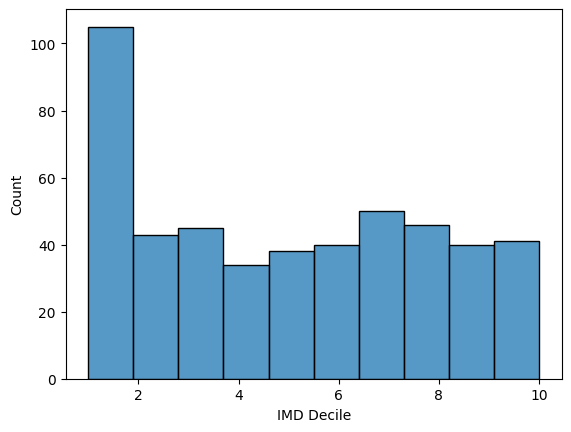

In [22]:
# We will use histograms to observe the shape of our variable datasets
# The results of this will allow us to see if the data is suitable for linear regression analysis
ax = sns.histplot(data=raw_imd,
             x="observation")
ax.set(xlabel='IMD Decile',
       ylabel='Count')

In [23]:
# Leeds LSOAs are relatively evenly mixed across their designated IMD decile, aside from IMD decile one which is the most prevalent (>100 entries)
# This is a significant over-representation of highly deprived areas within Leeds and would warrant further study in a separate report

[Text(0.5, 0, 'Attendance %'), Text(0, 0.5, 'Count')]

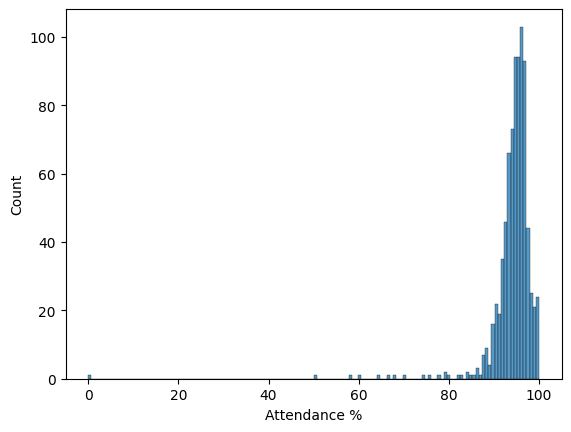

In [24]:
# We will use histograms to observe the shape of our variable datasets
# The results of this will allow us to see if the data is suitable for linear regression analysis
ax = sns.histplot(data=raw_attendance,
             x="Attendance (%)")
ax.set(xlabel='Attendance %',
       ylabel='Count')

In [25]:
# The attendance data skews negatively to the left, with a majority of data points having a value between 0.8 and 1, the values appear to follow a normal distribution in that range
# The outlier at 0% is particularly apparent in the visualisation

<Axes: >

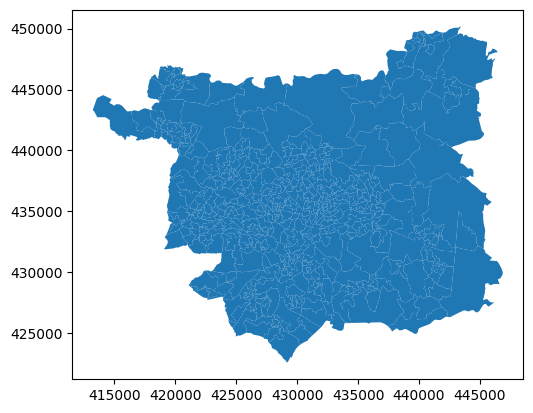

In [26]:
# Use the .plot() function to plot the leeds_lsoa file to see if they show the correct area
raw_leeds_lsoa.plot()

In [27]:
# When plotted the LSOAs reflect the shape of Leeds, confirming the dataset contains the LSOAs we need

## 3. Data Cleaning

Data cleaning will focus on overcoming any obstacles to unifying the deprivation, attendance and Leeds LSOA geometry datasets into a single merged dataset. This includes unifying the naming scheme for the LSOA columns in each dataset, and in the case of the deprivation data removing the first 11 characters so that the LSOA code is in the same format as the other two datasets.

In [28]:
# The deprivation, attendance and geometry datasets all use LSOA codes
# The merge for this project will be based around them
# To do this they need a unified name to call when running the merge command
# First we need to edit the LSOA codes within the deprivation dataset so that they are in the same format as the other two datasets (found at: https://stackoverflow.com/questions/72159679/how-to-remove-the-first-n-character-from-all-the-cells-in-a-column-using-python)
raw_imd['lsoalabel'] = raw_imd['lsoalabel'].str.slice(start=11)

# Now we can unify the columns under a single name by renaming them. In this case we will use the name LSOA11 from the attendance data set, renaming the other two columns to LSOA11 to match
clean_deprivation = raw_imd.rename(columns={'lsoalabel': 'LSOA11'})
clean_leeds_lsoa = raw_leeds_lsoa.rename(columns={'LSOA11CD': 'LSOA11'})

/tmp/ipykernel_1380/366260632.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  raw_imd['lsoalabel'] = raw_imd['lsoalabel'].str.slice(start=11)


In [29]:
# Remove the outlying data point in the attendance dataset noted above
# If left in the data point will skew the results inordinately, as it represents so few actual attendance misses
clean_attendance = raw_attendance[raw_attendance['Attendance (%)'] != 0]

In [30]:
# Check that the 0 value has been removed
clean_attendance.describe()

,Total of possible sessions,Total sessions attended,Total sessions missed,Attendance (%)
count,818.000000,818.000000,818.000000,818.000000
mean,18269.591687,17203.878973,1065.712714,94.324817
std,16931.982712,15868.282450,1182.146100,4.266187
min,8.000000,8.000000,0.000000,50.400000
25%,1446.500000,1384.500000,92.250000,93.200000
50%,16434.500000,15621.500000,722.500000,95.000000
75%,30213.250000,28503.500000,1620.250000,96.500000
max,81264.000000,76721.000000,6551.000000,100.000000


In [31]:
# Check to see the above operations have worked correctly for the deprivation dataset using .head() to view column names and LSOA data
clean_deprivation.head()

,LSOA11,indlabel,observation,JSONBoundary,JSONPBoundary
0,E01011698,a. Index of Multiple Deprivation (IMD),9,http://maps.communities.gov.uk/geoserver/ows?s...,http://maps.communities.gov.uk/geoserver/ows?s...
10,E01011699,a. Index of Multiple Deprivation (IMD),10,http://maps.communities.gov.uk/geoserver/ows?s...,http://maps.communities.gov.uk/geoserver/ows?s...
20,E01011701,a. Index of Multiple Deprivation (IMD),10,http://maps.communities.gov.uk/geoserver/ows?s...,http://maps.communities.gov.uk/geoserver/ows?s...
30,E01011702,a. Index of Multiple Deprivation (IMD),10,http://maps.communities.gov.uk/geoserver/ows?s...,http://maps.communities.gov.uk/geoserver/ows?s...
40,E01011703,a. Index of Multiple Deprivation (IMD),10,http://maps.communities.gov.uk/geoserver/ows?s...,http://maps.communities.gov.uk/geoserver/ows?s...


In [32]:
# Check to see the above operations have worked correctly for the LSOA geometry dataset using .head() to view column names and LSOA data
clean_leeds_lsoa.head()

,LSOA11,LSOA11NM,LSOA11NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
0,E01011264,Leeds 011A,Leeds 011A,420937,441834,-1.68306,53.87230,5b73f1d6-e700-48ef-be2a-6d4df84d2842,"MULTIPOLYGON (((421354.459 442329.047, 421423...."
1,E01011265,Leeds 009A,Leeds 009A,418988,441949,-1.71269,53.87341,0c71cf77-20ed-4194-b448-712a6507facc,"MULTIPOLYGON (((418598.457 442763.114, 418637...."
2,E01011266,Leeds 008A,Leeds 008A,417488,442614,-1.73547,53.87944,cc1386de-c24d-4ee1-bc24-3552659e5ba8,"MULTIPOLYGON (((417619.814 443438.729, 417810...."
3,E01011267,Leeds 009B,Leeds 009B,419639,442024,-1.70279,53.87406,18be375e-203b-4a2b-99d9-beaef78bfdfe,"MULTIPOLYGON (((419594.66 442296.822, 419657.5..."
4,E01011268,Leeds 010A,Leeds 010A,420222,441936,-1.69393,53.87325,3770231f-3ed5-4aae-8bca-42f2a16f65c6,"MULTIPOLYGON (((420308.62 442015.353, 420322.6..."


In [33]:
# Datasets now have unified names and formats for their LSOA data
# Can now merge them into a unified dataset with which we can perform analysis and create visualisations

In [34]:
# Before we can perform analysis on our two variables we first need to merge them into a single dataset
# Use an inner join so that only LSOAs within the dataset are ones with deprivation deciles and attendance records
deprivation_attendance_merge = pd.merge(clean_attendance, clean_deprivation, on="LSOA11", how="inner")

In [35]:
# Check the datasets has merged properly
deprivation_attendance_merge.head()

,LSOA11,Total of possible sessions,Total sessions attended,Total sessions missed,Attendance (%),indlabel,observation,JSONBoundary,JSONPBoundary
0,E01011264,23793,22507,1286,94.6,a. Index of Multiple Deprivation (IMD),6,http://maps.communities.gov.uk/geoserver/ows?s...,http://maps.communities.gov.uk/geoserver/ows?s...
1,E01011265,39477,37394,2083,94.7,a. Index of Multiple Deprivation (IMD),7,http://maps.communities.gov.uk/geoserver/ows?s...,http://maps.communities.gov.uk/geoserver/ows?s...
2,E01011266,45268,44063,1205,97.3,a. Index of Multiple Deprivation (IMD),10,http://maps.communities.gov.uk/geoserver/ows?s...,http://maps.communities.gov.uk/geoserver/ows?s...
3,E01011267,41139,37151,3988,90.3,a. Index of Multiple Deprivation (IMD),3,http://maps.communities.gov.uk/geoserver/ows?s...,http://maps.communities.gov.uk/geoserver/ows?s...
4,E01011268,31390,29576,1814,94.2,a. Index of Multiple Deprivation (IMD),2,http://maps.communities.gov.uk/geoserver/ows?s...,http://maps.communities.gov.uk/geoserver/ows?s...


In [36]:
deprivation_attendance_merge.describe()

,Total of possible sessions,Total sessions attended,Total sessions missed,Attendance (%),observation
count,480.000000,480.000000,480.000000,480.000000,480.000000
mean,28973.829167,27281.868750,1691.960417,94.465000,4.939583
std,13950.371897,12982.725332,1167.561682,2.117268,3.097999
min,310.000000,307.000000,3.000000,86.200000,1.000000
25%,20529.250000,19378.750000,866.250000,93.200000,2.000000
50%,28027.000000,26593.000000,1428.500000,94.750000,5.000000
75%,36162.250000,33654.000000,2214.250000,96.100000,8.000000
max,81264.000000,76721.000000,6551.000000,99.400000,10.000000


In [37]:
# The merge still has 480 unique entries, plenty to form a linear regression model from
# The merge has also significantly cut down on the number of attendance records, from 819 to 480
# This indicates that the attendance data set covers areas outside of the leeds LSOAs. These were likely rural areas with relatively low numbers of attendance records, as seen by their removal causing a substantial increase to both the minimum total and 25th percentile of possible sessions and sessions attended in the merged dataset
# The total number of data points is slightly lower than expected, at 480 instead of 482
# This can be explained through the removal of an anomalously low value (discussed above) and one LSOA not having matching records between IMD decile and attendance rates, being removed by the inner join

## 4. Non-Spatial Analysis

The non-spatial analysis aspect of this report will use a linear regression model to find whether there is a statistically significant relationship between deprivation and secondary school attendance rates.

Linear regression (OLS) was chosen due to the nature of the data used in this report. Both variables are expressed as continuous, measurable numbers and have a clear direction with an independent variable (IMD) and dependent variable (Attendance %). Using OLS was the clearest way of showing any potential relationship between the variables, allowing for the creation of an interpretable slope through both summary statistics and a regression line plot. Spearman's rank was considered as an alternative, but was not proceeded with as later sections of this report required the creation of predictions and residuals for spatial analysis. The output of OLS, an interpretable slope, was deemed to be of more use to an audience of policy-makers than a singular correlation coefficient produced from Spearman's rank.

In [38]:
# Perform linear regression to find if there is a statistically significant relationship between secondary school attendance and area deprivation
# Define the independent and dependent variables as X and Y
X = deprivation_attendance_merge['observation']  # Independent variable (X)
y = deprivation_attendance_merge['Attendance (%)']  # Dependent variable (Y)


# Add a constant (intercept) to the independent variable
X = sm.add_constant(X)

# Run the OLS regression model
ols_model = sm.OLS(y, X).fit()


# Print results of the OLS regression
print(ols_model.summary())

# Print a line to create a clear seperation between the two outputs:
print('=' * 91)

# Print the p-values of the OLS model to 2 d.p.
observation_p = ols_model.pvalues["observation"]
print('P-value for observed IMD Decile:', f'{observation_p:.2e}')

                            OLS Regression Results                            
Dep. Variable:         Attendance (%)   R-squared:                       0.426
Model:                            OLS   Adj. R-squared:                  0.425
Method:                 Least Squares   F-statistic:                     355.1
Date:                Wed, 26 Aug 2026   Prob (F-statistic):           1.20e-59
Time:                        15:57:29   Log-Likelihood:                -907.31
No. Observations:                 480   AIC:                             1819.
Df Residuals:                     478   BIC:                             1827.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          92.2610      0.138    668.473      

In [39]:
# Shown above are the results of the OLS regression model run between IMD decile and secondary school attendance
# The model reports an R^2 value of 0.426, indicating that 42.6% of variance in secondary school attendance (%) is caused by differing IMD deciles in Leeds LSOAs
# The model has a p-value of 1.20e-59, far below the cutoff for a 99% confidence interval (0.001)
# This shows that the results of this OLS regression, and the trends seen within it, should be treated as statistically significant

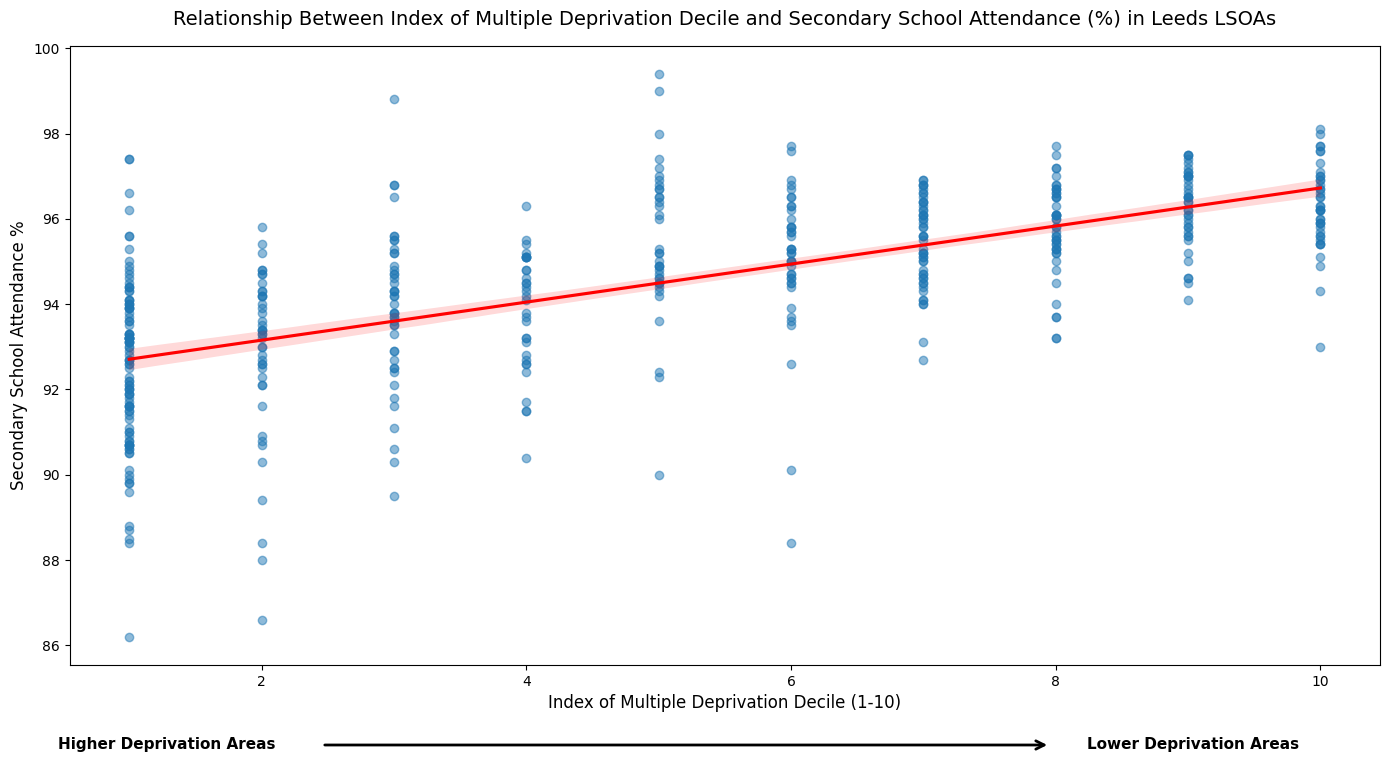

In [61]:
# Use Seaborn to create a scatter plot with a fitted regression line showing the relationship between deprivation and secondary school attendance
fig, ax = plt.subplots(figsize=(14, 8))
sns.regplot(
    data=deprivation_attendance_merge,
    x='observation',
    y='Attendance (%)',
    scatter_kws={'alpha': 0.5, 'color': '#1f77b4'},  # Semi-transparent blue dots to show overlaps between points
    line_kws={'color': '#FF0000'})    # Solid red regression line, stands out and is colour-blind accessible

# Add titles and labels to the plot
ax.set_title('Relationship Between Index of Multiple Deprivation Decile and Secondary School Attendance (%) in Leeds LSOAs', fontsize=14, pad=15)
ax.set_xlabel('Index of Multiple Deprivation Decile (1-10)', fontsize=12)
ax.set_ylabel('Secondary School Attendance %', fontsize=12)

# Add an arrow to communicate that a higher IMD decile equates to a less deprivated area
plt.subplots_adjust(bottom=0.18)

# Left Label: "More Deprived Area"
fig.text(
    0.20, 0.063,
    "Higher Deprivation Areas",
    fontsize=11,
    fontweight='bold',
    color='#000000',
    ha='right',
    va='center')

# Center Arrow: Points from left to right between the two text labels
ax.annotate(
    "",
    xy=(0.75, 0.04),             # Arrowhead end point (Right)
    xycoords='figure fraction',
    xytext=(0.23, 0.04),          # Arrow start point (Left)
    textcoords='figure fraction',
    arrowprops=dict(
        arrowstyle="->",          # Right-pointing arrow
        color="#000000",
        linewidth=2,
        mutation_scale=15))

# Right Label: "Less Deprived Area"
fig.text(
    0.78, 0.063,
    "Lower Deprivation Areas",
    fontsize=11,
    fontweight='bold',
    color='#000000',
    ha='left',
    va='center')

# Show the plot
plt.tight_layout()
plt.show()

# Save the created figure for upload to GitHub
fig.savefig('Regression_plot')

This plot was designed to be presented to policy-makers within Leeds City Council, providing insight into the relationship between the IMD decile of Leeds LSOAs and recorded Sencondary School Attendance %.

The non-spatial plot for this report shows the relationship between Index of Multiple Deprivation decile and secondary school attendance across different LSOAs in Leeds. The plot indicates a positive relationship between lower deprivation and higher attendance rates, shown by the fitted regression line tilting upwards. A colour scheme of white, blue and red was used to create sharp contrasts between the background, data points and regression line. An alpha of 0.5 was used for the data points to display overlapping points rather than obscuring them. The plot title and axis labels were customised to be presented in plain English without any technical language to allow for easy interpretation by a wider range of viewers. A custom arrow was included below the X-axis to further aid ease of understanding, providing information on the scale used to assess deprivation (10 least deprived, 1 most deprived).

A scatter plot was chosen as the non-spatial visualisation of this report primarily for its simplicity. The plot features all data points and directly illustrates the fitted regression line mentioned elsewhere in this report. The main issue for the above visualisation is that, because the X-axis is taken from a decile format, there is significant overlapping of data points which makes them difficult to interpret individually. This could be solved through the use of box plots or violin plots in place of the individual points. However, use of such techniques would require additional explanation above what a visualisation designed to be immediately interpretable by non-technical audiences should require. A bar chart showing the mean attendance % values of each decile was also considered but was rejected due to providing no insight into the variation found within each decile. The scatter plot was found to be an appropriate compromise between easy interpretability and ability to showcase variance, which would later be expanded upon in the spatial visualisation section of this report.

## 5: Spatial Analysis

The non-spatial analysis aspect of this report will use a linear regression model to find whether there is a statistically significant relationship between deprivation and secondary school attendance rates.

In [41]:
# To perform spatial analysis we need to include the LSOA geometry dataset within our merged dataset
# Use an inner join so that only LSOA geometry data with available deprivation deciles and attendance records are included within the merged dataset
spatial_deprivation_attendance_merge = pd.merge(clean_leeds_lsoa, deprivation_attendance_merge, on="LSOA11", how="inner")

In [42]:
spatial_deprivation_attendance_merge.head()

,LSOA11,LSOA11NM,LSOA11NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry,Total of possible sessions,Total sessions attended,Total sessions missed,Attendance (%),indlabel,observation,JSONBoundary,JSONPBoundary
0,E01011264,Leeds 011A,Leeds 011A,420937,441834,-1.68306,53.87230,5b73f1d6-e700-48ef-be2a-6d4df84d2842,"MULTIPOLYGON (((421354.459 442329.047, 421423....",23793,22507,1286,94.6,a. Index of Multiple Deprivation (IMD),6,http://maps.communities.gov.uk/geoserver/ows?s...,http://maps.communities.gov.uk/geoserver/ows?s...
1,E01011265,Leeds 009A,Leeds 009A,418988,441949,-1.71269,53.87341,0c71cf77-20ed-4194-b448-712a6507facc,"MULTIPOLYGON (((418598.457 442763.114, 418637....",39477,37394,2083,94.7,a. Index of Multiple Deprivation (IMD),7,http://maps.communities.gov.uk/geoserver/ows?s...,http://maps.communities.gov.uk/geoserver/ows?s...
2,E01011266,Leeds 008A,Leeds 008A,417488,442614,-1.73547,53.87944,cc1386de-c24d-4ee1-bc24-3552659e5ba8,"MULTIPOLYGON (((417619.814 443438.729, 417810....",45268,44063,1205,97.3,a. Index of Multiple Deprivation (IMD),10,http://maps.communities.gov.uk/geoserver/ows?s...,http://maps.communities.gov.uk/geoserver/ows?s...
3,E01011267,Leeds 009B,Leeds 009B,419639,442024,-1.70279,53.87406,18be375e-203b-4a2b-99d9-beaef78bfdfe,"MULTIPOLYGON (((419594.66 442296.822, 419657.5...",41139,37151,3988,90.3,a. Index of Multiple Deprivation (IMD),3,http://maps.communities.gov.uk/geoserver/ows?s...,http://maps.communities.gov.uk/geoserver/ows?s...
4,E01011268,Leeds 010A,Leeds 010A,420222,441936,-1.69393,53.87325,3770231f-3ed5-4aae-8bca-42f2a16f65c6,"MULTIPOLYGON (((420308.62 442015.353, 420322.6...",31390,29576,1814,94.2,a. Index of Multiple Deprivation (IMD),2,http://maps.communities.gov.uk/geoserver/ows?s...,http://maps.communities.gov.uk/geoserver/ows?s...


In [43]:
spatial_deprivation_attendance_merge.describe()

,BNG_E,BNG_N,LONG,LAT,Total of possible sessions,Total sessions attended,Total sessions missed,Attendance (%),observation
count,480.000000,480.000000,480.000000,480.000000,480.000000,480.000000,480.000000,480.000000,480.000000
mean,429746.525000,435005.785417,-1.549749,53.810475,28973.829167,27281.868750,1691.960417,94.465000,4.939583
std,5810.978191,4839.424034,0.088241,0.043512,13950.371897,12982.725332,1167.561682,2.117268,3.097999
min,415777.000000,424017.000000,-1.761510,53.711780,310.000000,307.000000,3.000000,86.200000,1.000000
25%,425634.250000,432152.500000,-1.612585,53.784998,20529.250000,19378.750000,866.250000,93.200000,2.000000
50%,429455.000000,434934.000000,-1.554065,53.809910,28027.000000,26593.000000,1428.500000,94.750000,5.000000
75%,433262.000000,437673.250000,-1.496512,53.834630,36162.250000,33654.000000,2214.250000,96.100000,8.000000
max,444139.000000,449492.000000,-1.330270,53.940040,81264.000000,76721.000000,6551.000000,99.400000,10.000000


In [44]:
# Merge has been successful, each of the 480 rows used within the linear regression now have their associated LSOA geometry data

In [45]:
# Add a residuals column into the master dataset to use when plotting
spatial_deprivation_attendance_merge['residual'] = ols_model.resid

# Check to see if OLS residuals sum to 0 before plotting, if not then alignment has failed
print(f"Rows in GeoDataFrame: {len(spatial_deprivation_attendance_merge)}")
print(f"Residuals assigned:   {spatial_deprivation_attendance_merge['residual'].notna().sum()}")
print(f"Mean residual:        {spatial_deprivation_attendance_merge['residual'].mean():.8f}")

Rows in GeoDataFrame: 480
Residuals assigned:   480
Mean residual:        -0.00000000


In [46]:
# Convert CRS to espg=3857 (Web Mercator) to work with contextily
spatial_deprivation_attendance_merge = spatial_deprivation_attendance_merge.to_crs(epsg=3857)

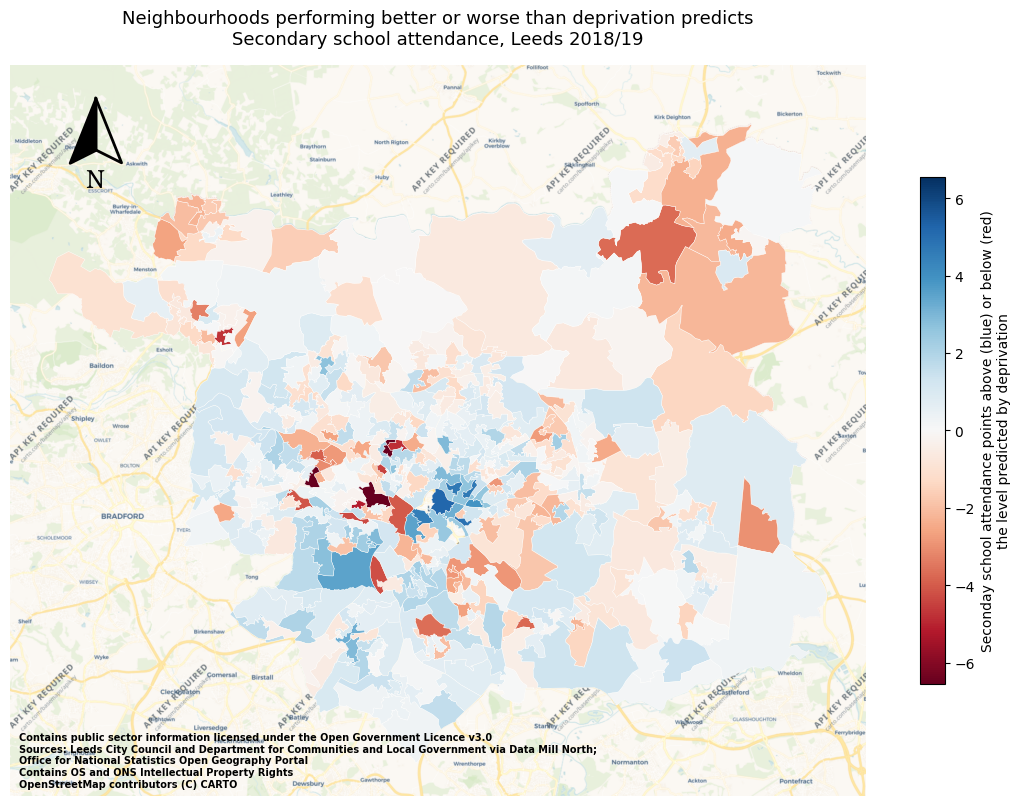

In [64]:
# Centre the colour scale on zero so that the diverging colour shceme works properly
vmax = spatial_deprivation_attendance_merge['residual'].abs().max()
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

# Set size of the plot, including extra space underneath to make room for acknowledgements
fig, ax = plt.subplots(figsize=(11, 11))
plt.subplots_adjust(bottom=0.5)

# The residual choropleth on top
spatial_deprivation_attendance_merge.plot(
    column='residual',
    cmap='RdBu',          # diverging colourmap, chosen as it is colourblind inclusive
    norm=norm,            # symmetric around zero using defined norm used at the start of the cell
    linewidth=0.3,
    alpha=1,
    edgecolor='white',
    legend=True,
    legend_kwds={         # Add text to legend to make interpretation easier
        'label': 'Seconday school attendance points above (blue) or below (red)\n'
                 'the level predicted by deprivation',
        'shrink': 0.5
    },
    ax=ax
)

ax.set_title('Neighbourhoods performing better or worse than deprivation predicts\n'
             'Secondary school attendance, Leeds 2018/19',
             fontsize=13, pad=15)
ax.set_axis_off()


# Add a North Arrow
add_north_arrow(ax=ax,
                scale=.75,
                xlim_pos=0.1,
                ylim_pos=.90,
                color='#000000',
                text_scaler=2,
                text_yT=-1.25)


# Add a basemap using contextily
ctx.add_basemap(ax,source=ctx.providers.CartoDB.Voyager,
                zoom=12,
                attribution=False,  # Disabled in-built attribution as it clashes with other acknowledgements, included with other attribution notices
                crs=spatial_deprivation_attendance_merge.crs)

# Add attribution notices to the plot following license agreements of public data

ax.text(0.01, 0.01,
        'Contains public sector information licensed under the Open Government '
        'Licence v3.0\nSources: Leeds City Council and Department for Communities and Local Government via Data Mill North; '
        '\nOffice for National Statistics Open Geography Portal\nContains OS and ONS Intellectual Property Rights'
        '\nOpenStreetMap contributors (C) CARTO',
        transform=ax.transAxes,
        fontsize=7,
        color='#000000',
        weight='bold',
        va='bottom')

plt.tight_layout()
plt.show()

fig.savefig('Residual_plot')

The residuals plot highlights LSOAs within Leeds which do not follow the discovered trend between higher levels of deprivation and lower secondary school attendance within the used datasets. Through this, the plot can highlight areas which warrant further investigation by local decision makers who are allocating attention across Leeds.  Deprived areas within Leeds with abnormally high secondary school attendance rates are worth further study, so that the unique traits leading to those higher attendance rates might be identified. This could allow for those unique traits to be transposed into other deprived areas to improve attendance rates city-wide.

A residuals plot was chosen as the spatial visualisation for its unique ability to present actionable insights to decision-makers from the variation mentioned throughout this report. The relationship between an LSOA's IMD decile and secondary school attendance is shown effectively through the scatter plot above, whereas the residual builds on those findings and presents areas for investigation which break the patterns discussed elsewhere. A pair of simple choropleth maps showing spatial variation of IMD deciles and secondary school attendance within Leeds was considered, but was deemed to be redundant. The locations of deprived areas and areas with low secondary school attendance rates can easily be interrogated in future studies.  

A diverging colour map was used due to its ability to naturally show the relationship between noted positive and negative regions against the expected trend. This allows different trends seen across Leeds to be intuitively shown, with LSOA polygons becoming successively darker as they stray further away from the expected trend. The RdBu colourmap was chosen above others because it is colourblind inclusive, with clear differences in lightness values between Blue, Red and White. A deliberate choice was made to avoid using a quantile classification system, instead making use of ‘TwoSlopeNorm’ to fix the midpoint of the scale at 0. By doing this the map is able to accurately highlight overestimate and underestimation within the dataset, rather than showing deviation away from an arbitrary midpoint in the data.

Deliberate efforts were made to ensure that the created plot was easily readable and accessible to non-technical audiences. To achieve this no raw variable names were included on the final plot, instead being replaced by a descriptive sentence to accompany the legend. The title follows similar logic, being a  brief explanation of what the plot is showing using plain, non-technical language.


## 6: Limitations and Conclusion

There are limitations with this study that must be acknowledged. One such limitation is the temporal mismatch between the deprivation and school attendance data sets, being from 2015 and 2019 respectively. It is possible that deprivation levels within Leeds LSOAs could have changed during that period, creating unknown influence on attendance rates. A further study using updated data would remedy this issue but require commissioning a new survey of multiple deprivation within Leeds, alongside the release of more recent secondary school attendance records. However, the choice to use IMD data from 2015 was deliberate as it provides insight into the conditions that preceded the outcome of differing attendance records. Since this study was attempting to find an association between the two variables, using an older deprivation dataset whose findings have had time to impact the local population was deemed correct.

The study also focuses solely on the combined Index of Multiple Deprivation decile to perform its analysis. While this metric provides a holistic view of deprivation within neighbourhoods it does not allow for analysis of the differing relationships between different measures (Income deprivation, health deprivation, crime rates, employment deprivation, etc) on secondary school attendance rates. However, the single IMD decile suits the bivariate assessment methods used in this report and maintains interpretability for non-technical audiences by providing a single output. An investigation into which aspects of deprivation hold the most influence on secondary school attendance warrants its own study and falls outside the scope of this report.

The attendance data set also provides no information on trends at individual schools, instead providing a figure which aggregates student attendance across many different schools. As mentioned above this is beneficial as it views the same resident population model as the deprivation dataset, but it limits the depth of investigation we can perform with our results. The format of the attendance dataset means nothing can be attributed to the practices of individual schools with higher relative attendance records. Valuable strategies which could be transposed to other schools are left undiscovered because of this.

Perhaps the most important acknowledgement to make following this report is that we cannot establish a direct link between higher deprivation levels and lower secondary school attendance rates despite the correlation found between the two variables. Shared underlying causes of deprivation and lower secondary school attendances are not measured in this analysis. However, that is not to say that the results of this report provide no actionable benefits. Statistical analysis has shown that varying levels of deprivation explains 42.6% of the variation in secondary school attendance rates, producing an R$^{2}$ value of 0.426. While this leaves roughly 60% of variation unaccounted for, it is still a substantial influence on attendance rates and, paired with knowledge of areas within Leeds that do not follow the established trend uniformly from the residuals plot, provides strong justification for decision-makers to commit to further study.


## 7. Bibliography

Klein, M., Sosu, E.M. and Dare, S. (2020) 'Mapping inequalities in school attendance: The relationship between dimensions of socioeconomic status and forms of school absence', Children and Youth Services Review, 118, art. no. 105432. Available at: https://doi.org/10.1016/j.childyouth.2020.105432.

Middleton, A., Watson, M. and Anderson, J.K. (2026) 'What school-based interventions work to improve attendance in secondary school students with persistent absence? A systematic review', Frontiers in Child and Adolescent Psychiatry, 4, art. no. 1603680. Available at: https://doi.org/10.3389/frcha.2025.1603680.